##Read and Transform the Data

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
!pip install optuna
import optuna
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from google.colab import drive
drive.mount('/content/drive')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # Check if GPU (cuda) is available
print(f"Using device: {device}")


# -----------------------------------------------------------------------------
# READ DATA (UNSCALED) AND TRANSPOSE
# -----------------------------------------------------------------------------
train_path = "/content/drive/MyDrive/playing-the-stock-market-is-a-fools-game/train.csv"
submission_path = "/content/drive/MyDrive/playing-the-stock-market-is-a-fools-game/sample_submission.csv"
train_df = pd.read_csv(train_path)                                # Read the data into a pandas dataframe
submission_df = pd.read_csv(submission_path)

# train_df has shape (442, 3022 + 1) => ID + daily changes from 05/04/2010 to 31/03/2022
raw_data = train_df.set_index("ID").values.astype(np.float32)     # Set the "ID" column as the index (remove it from the data columns).
raw_data = raw_data.T                                             # Transpose the array to (3022, 442), so that rows=days, cols=companies.


# -----------------------------------------------------------------------------
# SPLIT INTO 75% TRAIN AND 25% VAL, THEN FIT SCALER ONLY ON TRAIN
# -----------------------------------------------------------------------------
split_idx = int(0.8 * raw_data.shape[0])

train_raw = raw_data[:split_idx]
val_raw   = raw_data[split_idx:]

# Fit scaler only on the training portion
scaler = MinMaxScaler(feature_range=(-1, 1))   # Create a MinMaxScaler that transforms data into the range [-1, 1].
scaler.fit(train_raw)       # Learn the scaling parameters from the training split only, to avoid data leakage from the validation set.

# Transform train + val splits with the same scaler
train_split = scaler.transform(train_raw)  # Shape --> (0.75*3022, 442).
val_split   = scaler.transform(val_raw)    # Shape --> (0.25*3022, 442).

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


##Data Generation (Random Subsequences)

In [ ]:
# -----------------------------------------------------------------------------
# DATA GENERATION (Random subsequences)
# -----------------------------------------------------------------------------
def get_random_subsequence(data, device, seq_length):
    # Extract a random [seq_length x num_features] subsequence from 'data'.
    n = data.shape[0]
    if n <= seq_length:
        raise ValueError("Sequence length cannot exceed total number of rows.")
    start_idx = np.random.randint(0, n - seq_length)     # Pick a random start_idx so that start_idx + seq_length is within bounds. Slice out seq_length consecutive rows.
    subseq = data[start_idx:start_idx + seq_length]
    return torch.from_numpy(subseq).float().to(device)   # Convert the NumPy slice into a PyTorch tensor and move it to the specified device.

# Now define a function to use get_random_subsequence to grab a random window of length seq_length
def generate_random_training_sequence(data, device, seq_length):    # Return (X, y) where X is [seq_length-1 x num_features], and y is [seq_length-1 x num_features] shifted by 1 step.
    frames = get_random_subsequence(data, device, seq_length)       # frames shape: (seq_length, num_features)
    X = frames[:-1]                                                 # Split the window into (X, y) pairs such that X has all but the last row.
    y = frames[1:]                                                  # Split the window into (X, y) pairs such that y has all but the first row.
    return X, y


# Now define a function to generate a list of random (X, y) pairs.
def generate_random_training_sequences(data, device, n, seq_length):
    X_all, y_all = [], []
    for _ in range(n):     # Call generate_random_training_sequence n times to create a list of (X, y) pairs.
        X, y = generate_random_training_sequence(data, device, seq_length)
        X_all.append(X)
        y_all.append(y)
    return X_all, y_all    # Return two lists, X_all and y_all, which can be turned into a dataset.


##Define the LSTM Model

In [ ]:
# -----------------------------------------------------------------------------
# DEFINE MODEL (LSTM)
# -----------------------------------------------------------------------------
def create_model(input_dim, hidden_dim, output_dim, num_layers, dropout):
    class Net(nn.Module):
        def __init__(self):
            super(Net, self).__init__()
            self.num_layers = num_layers
            self.hidden_dim = hidden_dim
            self.rnn = nn.LSTM(input_dim, hidden_dim, num_layers,
                                batch_first=True, dropout=dropout)
            self.linear = nn.Linear(hidden_dim, output_dim)   # Create a linear layer to map the hidden state to the output dimension.

        def init_hidden(self, batch_size):                    # Return zero-initialized hidden and cell states for the LSTM, sized according to the number of layers and hidden dimensions.
            return (torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device),
                    torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device))

        def forward(self, x):                          # Receives x of shape [batch_size, seq_length, input_dim].
            batch_size = x.size(0)
            h0, c0 = self.init_hidden(batch_size)      # Initialize hidden states h0 and c0.
            out, _ = self.rnn(x, (h0, c0))             # Feed x and (h0, c0) into the LSTM, which returns out for all timesteps
            last_out = out[:, -1, :]                   # Slice out[:, -1, :] to get the output at the last timestep for each sequence
            return self.linear(last_out)               # Passe that last output through the linear layer to produce the final prediction

    return Net().to(device)

##Define the Optuna Objective (Train on the Training Split and evaluate on the Validation Split)

In [ ]:
# -----------------------------------------------------------------------------
# DEFINE OPTUNA OBJECTIVE
# -----------------------------------------------------------------------------
def objective(trial):
    # Hyperparameters to search
    hidden_dim = trial.suggest_int("hidden_dim", 128, 512)
    num_layers = trial.suggest_int("num_layers", 1, 6)
    dropout    = trial.suggest_float("dropout", 0.2, 0.6)
    lr         = trial.suggest_float("lr", 1e-6, 1e-1, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "RMSprop", "SGD"])
    seq_length = trial.suggest_int("seq_length", 2, 30)
    batch_size = trial.suggest_int("batch_size", 16, 128)
    num_sequences = trial.suggest_int("num_sequences", 100, 600)   # How many random subsequences to generate each epoch.

    # Model & Optimizer
    input_dim = train_split.shape[1]     # The number of input features is 442 (one per company).
    model = create_model(                # Build the LSTM model with the sampled hyperparameters.
        input_dim  = input_dim,
        hidden_dim = hidden_dim,
        output_dim = input_dim,
        num_layers = num_layers,
        dropout    = dropout
    )
    optimizer_class = getattr(optim, optimizer_name)         # Dynamically fetch the optimizer class.
    optimizer = optimizer_class(model.parameters(), lr=lr)   # Instantiate the optimizer with the chosen learning rate
    criterion = nn.MSELoss()                                 # Use Mean Squared Error as the loss function.

    X_train, y_train = generate_random_training_sequences(   # Generate random subsequences for the training set using the previously defined functions.
        data=train_split,
        device=device,
        n=num_sequences,
        seq_length=seq_length
    )

    X_val, y_val = generate_random_training_sequences(       # Generate random subsequences for the validation set using the previously defined functions.
        data=val_split,
        device=device,
        n=int(num_sequences/2),
        seq_length=seq_length
    )

    # Wrap the (X, y) pairs in PyTorch DataLoaders for convenient mini-batch iteration
    train_loader = DataLoader(list(zip(X_train, y_train)), batch_size=batch_size, shuffle=True)  # Shuffle=True for training loader to randomize the batch order each epoch.
    val_loader   = DataLoader(list(zip(X_val, y_val)),     batch_size=batch_size, shuffle=False)

    epochs = 200                            # Number of training epochs for each trial.
    for epoch in range(epochs):             # Training loop for the training split.
        model.train()                       # Set the model to training mode.
        for Xb, yb in train_loader:
            optimizer.zero_grad()           # Zero the gradients
            pred = model(Xb)
            target = yb[:, -1, :]           # Compute predictions --> shape: [batch_size, 442]
            loss = criterion(pred, target)  # Compute MSE loss.
            loss.backward()                 # Backprobagate
            optimizer.step()                # Update the model parameters

        model.eval()                  # Set the model to evaluation mode.
        val_losses = []
        with torch.no_grad():         # Disables gradient computation with torch.no_grad().
            for Xb, yb in val_loader: # Computes validation loss on each batch and collects them in val_losses.
                pred = model(Xb)
                target = yb[:, -1, :]
                loss = criterion(pred, target)
                val_losses.append(loss.item())

        avg_val_loss = np.mean(val_losses)  # Average the validation losses to get avg_val_loss.
        trial.report(avg_val_loss, epoch)   # Reports the intermediate result to Optuna
        if trial.should_prune():            # Allow Optuna to prune this trial early if it’s not promising
            raise optuna.exceptions.TrialPruned()

    return avg_val_loss     # Return the final validation loss after all epochs.


##Run Optuna Optimization, retrain the Model with the best Hyperparameters and make Final Predictions on April 1st, 2022

In [ ]:
# -----------------------------------------------------------------------------
# RUN OPTUNA OPTIMIZATION
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    study = optuna.create_study(direction="minimize")    # Create an Optuna study object, telling it we want to minimize our objective function.
    study.optimize(objective, n_trials=60, timeout=600)  # Run maximum of 60 trials or stop after 600 seconds.

    print("=========================================")   # Print out the summary of the completed trials, including the best trial’s final MSE and hyperparameters.
    print("Number of finished trials:", len(study.trials))
    print("Best trial:")
    best_trial = study.best_trial
    print(f"  Value (MSE): {best_trial.value}")
    print("  Params:")
    for k, v in best_trial.params.items():
        print(f"    {k}: {v}")

    # -----------------------------------------------------------------------------
    # RETRAIN MODEL ON FULL DATASET USING BEST PARAMS
    # -----------------------------------------------------------------------------

    full_data = scaler.transform(raw_data) # After finding the best hyperparameters, transform all of the data with the scaler to retrain on the entire dataset

    best_params = best_trial.params        # Retrieve the best hyperparameters from Optuna.
    input_dim   = full_data.shape[1]

    final_model = create_model(            # Build the final LSTM model with the best hyperparameters.
        input_dim  = input_dim,
        hidden_dim = best_params["hidden_dim"],
        output_dim = input_dim,
        num_layers = best_params["num_layers"],
        dropout    = best_params["dropout"]
    ).to(device)

    optimizer_class = getattr(optim, best_params["optimizer"])
    final_optimizer = optimizer_class(final_model.parameters(), lr=best_params["lr"])
    final_criterion = nn.MSELoss()

    seq_length   = best_params["seq_length"]
    batch_size   = best_params["batch_size"]
    num_sequences = best_params["num_sequences"]
    epochs       = 50                       # Train for 50 epochs

    X_all, y_all = generate_random_training_sequences(    # Generate random subsequences for the entire dataset
        data=full_data,
        device=device,
        n=num_sequences,
        seq_length=seq_length
    )
    final_loader = DataLoader(list(zip(X_all, y_all)), batch_size=batch_size, shuffle=True)   # Create a DataLoader for final training.

    for epoch in range(epochs):    # Final training loop over the entire dataset, using the best hyperparameters.
        final_model.train()
        for Xb, yb in final_loader:
            final_optimizer.zero_grad()
            pred = final_model(Xb)
            target = yb[:, -1, :]
            loss = final_criterion(pred, target)
            loss.backward()
            final_optimizer.step()

    # -----------------------------------------------------------------------------
    # MAKE FINAL PREDICTIONS FOR 1 APRIL 2022
    # -----------------------------------------------------------------------------
    final_model.eval()                                   #  Set the model to evaluation mode.
    with torch.no_grad():
        x_input = torch.tensor(full_data[-seq_length:, :], dtype=torch.float32, device=device)  # Grab the last seq_length days from the full dataset.
        x_input = x_input.unsqueeze(0)                   # Add a batch dimension, so shape becomes [1, seq_length, 442].
        prediction = final_model(x_input)                # Model outputs predictions for the next time step with shape --> [1, 442].
        prediction = prediction.cpu().numpy().flatten()  # Move the result back to CPU and converts to NumPy, resulting in shape [442]

    prediction_2d = prediction.reshape(1, -1)            # Reshape to [1, 442] to apply the scaler’s inverse transform.
    pred_inverted = scaler.inverse_transform(prediction_2d).flatten()  # Map the normalized predictions back to the original data scale.

    # -----------------------------------------------------------------------------
    # SAVE TO SUBMISSION FILE
    # -----------------------------------------------------------------------------
    submission_df["value"] = pred_inverted
    submission_df.to_csv("submission.csv", index=False)
    print("✅ Predictions saved to submission.csv")

[I 2025-03-27 11:41:57,355] A new study created in memory with name: no-name-bca491f5-c42d-413b-8db3-ee5d73553782
[I 2025-03-27 11:42:08,263] Trial 0 finished with value: 0.04545739106833935 and parameters: {'hidden_dim': 310, 'num_layers': 5, 'dropout': 0.48638147125609504, 'lr': 0.00016979287456433918, 'optimizer': 'RMSprop', 'seq_length': 11, 'batch_size': 113, 'num_sequences': 337}. Best is trial 0 with value: 0.04545739106833935.
[I 2025-03-27 11:42:23,049] Trial 1 finished with value: 0.0515525092681249 and parameters: {'hidden_dim': 320, 'num_layers': 2, 'dropout': 0.3435388294375763, 'lr': 0.0017657744457912634, 'optimizer': 'RMSprop', 'seq_length': 29, 'batch_size': 95, 'num_sequences': 417}. Best is trial 0 with value: 0.04545739106833935.
[I 2025-03-27 11:42:28,323] Trial 2 finished with value: 5.560345649719238 and parameters: {'hidden_dim': 408, 'num_layers': 4, 'dropout': 0.4437580396796507, 'lr': 0.03913192445581789, 'optimizer': 'RMSprop', 'seq_length': 12, 'batch_size'

Number of finished trials: 60
Best trial:
  Value (MSE): 0.03777437768876553
  Params:
    hidden_dim: 199
    num_layers: 2
    dropout: 0.48285107625183604
    lr: 0.0001504148769007368
    optimizer: RMSprop
    seq_length: 16
    batch_size: 30
    num_sequences: 270
✅ Predictions saved to submission.csv


## Print the Submission File and Save for Upload in Kaggle

In [ ]:
# Load the submission file
submission_df = pd.read_csv("submission.csv")

# Display the first few rows of the submission file
print(submission_df.head())

from google.colab import files

# Download the submission file
files.download("submission.csv")

          ID     value
0  company_0  0.845865
1  company_1  0.496979
2  company_2  0.695174
3  company_3  0.578252
4  company_4  0.609070


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Captum Interpretation

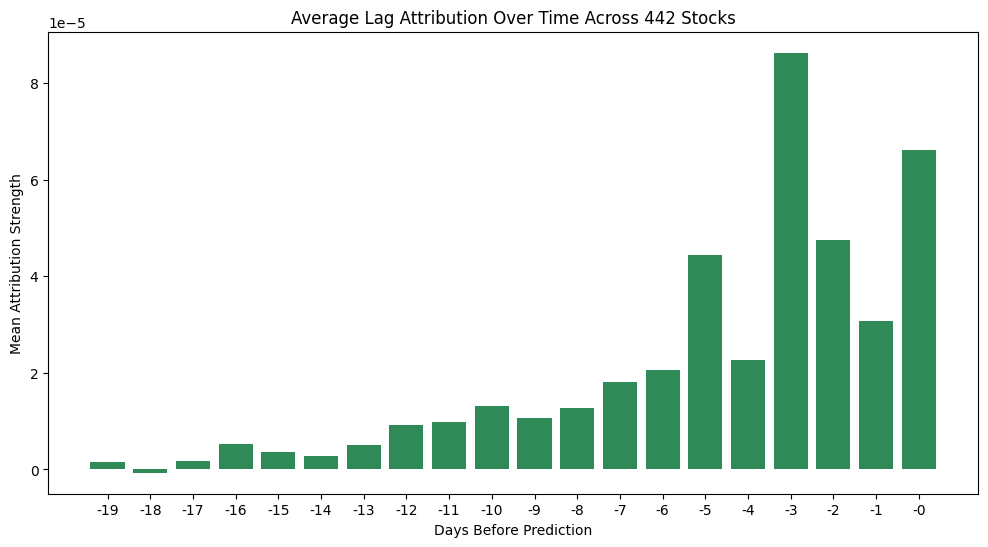

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
!pip install captum
from captum.attr import IntegratedGradients

# Set the model to training mode to allow RNN backward
final_model.train()

sample_seq = torch.tensor(val_split[-20:], dtype=torch.float32, device=device)   # Use the last 20 days from val_split as the sample input sequence.
input_seq = sample_seq.unsqueeze(0)                                              # Reshape to [1, seq_length, input_dim] i.e. [1, 10, 442]
input_seq.requires_grad_()

num_companies = 442
target_companies = np.random.choice(num_companies, num_companies, replace=False) # Select target companies (all companies here).

attributions_per_company = []

# Define a forward function that returns the full model output.
def forward_func_full(x):
    return final_model(x)                      # output shape: [batch, 442]

ig = IntegratedGradients(forward_func_full)    # Initialize Integrated Gradients outside the loop.

for target_company_index in target_companies:  # Loop over each target company and compute attributions via the target parameter.
    attr, delta = ig.attribute(input_seq, target=int(target_company_index),    # Compute attributions; pass the target index via the target parameter.
                           return_convergence_delta=True, n_steps=200)

    attr_np = attr.squeeze(0).detach().cpu().numpy()                           # shape becomes [20, 442]
    company_attr = attr_np[:, target_company_index]
    attributions_per_company.append(company_attr)

attributions_per_company = np.array(attributions_per_company)                  # Convert the list to a NumPy array; expected shape: (num_companies, 10)
mean_attributions = np.mean(attributions_per_company, axis=0)                  # Compute the average attribution of each past day across companies.

time_step_labels = [f"-{i}" for i in reversed(range(mean_attributions.shape[0]))]   # Generate labels for the time steps (e.g., "-10" (oldest) to "-1" (most recent)).

# Plot the average attribution importance.
plt.figure(figsize=(12, 6))
plt.bar(time_step_labels, mean_attributions, color="seagreen")
plt.xlabel("Days Before Prediction")
plt.ylabel("Mean Attribution Strength")
plt.title(f"Average Lag Attribution Over Time Across {num_companies} Stocks")
plt.show()

This plot shows how much each of the last 10 days (relative to the prediction day) contributed, on average, to the model’s final prediction across all 442 stocks. In other words, Integrated Gradients is highlighting which time steps the LSTM found most influential when predicting the next day’s movement. In short, the graph tells us that, on average, the LSTM is relying more heavily on certain recent days (in this case around 3–4 days before the prediction) than on others when forecasting the next day’s stock movement.
Lastly, it is obvious that there is a geometrical long-term decay over time, which is very reasonable considering that we have time-series for stocks. Next day's returns tend to be more influenced by their most recent data.